# **Project Name**    -  **Amazon Delivery Prediction**                       


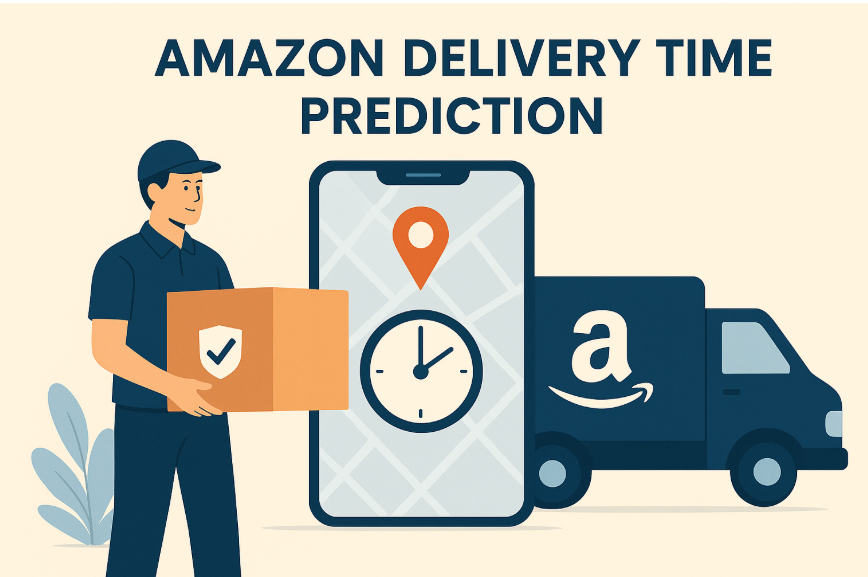



##### **Project Type**    - EDA
##### **Contribution**    - Individual
##### **Member Name -** SHREYA SACHAN

# **Project Summary -**

The growth of e-commerce has heightened the importance of timely delivery for customer satisfaction and operational efficiency. For a global platform like Amazon, predicting delivery times accurately is crucial because delays can lead to negative customer experiences, increased costs, and logistical challenges. Delivery time is influenced by multiple factors such as product dimensions, weight, shipping distance, traffic conditions, delivery method, and seasonal demand fluctuations. Traditional methods of estimation often rely on simple heuristics, which fail to account for the complex interactions between these variables.  

This project aims to accurately predict delivery times for e-commerce orders, specifically for Amazon, by analyzing historical order data. Delivery time depends on multiple factors including product dimensions, shipping distance, order weight, traffic conditions, and chosen shipping method. By leveraging machine learning regression models, the project identifies patterns and relationships in the data to provide precise delivery time predictions.

# **The workflow involves:**

**->Data Collection & Cleaning:** Handling missing values, outliers, and inconsistencies in the dataset to ensure quality inputs.

**->Exploratory Data Analysis (EDA):** Understanding key factors affecting delivery times, visualizing distributions, and uncovering trends.

**->Feature Engineering:** Creating meaningful features from raw data (e.g., distance between warehouse and delivery location, product category encoding).

**->Modeling**: Applying regression models (like Linear Regression, Random Forest, Gradient Boosting) to predict delivery times.

**->Evaluation:** Measuring model accuracy using metrics like RMSE (Root Mean Squared Error), MAE (Mean Absolute Error), and R² score.

**->Deployment:** Optionally integrating the model into a dashboard (e.g., Streamlit) to allow real-time delivery time estimation.

# **Skills Gained:**

1.Data preprocessing and cleaning

2.Exploratory Data Analysis (EDA)

3.Feature engineering and selection

4.Regression modeling and performance evaluation

5.Model deployment using Streamlit and MLflow

**Domain:**
E-commerce and Logistics

**Impact:**
Accurate delivery time prediction enables Amazon to optimize logistics, reduce operational costs, and improve customer satisfaction. It also allows for better resource allocation and planning, which is vital in handling peak demand periods and maintaining a competitive edge in e-commerce.

# **GitHub Link -**

https://github.com/shreya3090

# **Problem Statement**


E-commerce companies like Amazon face a critical challenge in accurately estimating delivery times for customer orders. Delays or unpredictable delivery times can lead to customer dissatisfaction, increased operational costs, and inefficiencies in logistics planning. Delivery times are influenced by multiple factors such as product size, weight, shipping distance, traffic conditions, and chosen delivery methods. Traditional estimation methods often fail to capture the complex relationships among these factors, resulting in inaccurate predictions.

This project aims to address this challenge by developing a machine learning model that predicts delivery times based on historical order data. By analyzing patterns in past deliveries and incorporating key features, the model can provide precise and reliable delivery time estimates, helping Amazon optimize its logistics, improve customer experience, and reduce operational inefficiencies.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [ ]:
# Cell 0 — optional: only if you plan to run ML code / streamlit / mlflow later
!pip install xgboost mlflow streamlit -q


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import radians, sin, cos, sqrt, asin
from sklearn.model_selection import train_test_split
import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set(style="whitegrid")
SEED = 42
np.random.seed(SEED)
%matplotlib inline

### Dataset Loading

In [ ]:
# Step 1: Mount Google Drive
from google.colab import drive

drive.mount('/content/drive')

# Step 2: Load dataset (update path if needed)
df = pd.read_csv("/content/drive/MyDrive/datasets/amazon_delivery.csv")

# Step 3: Dataset First View
print("First 5 Rows:\n")
print(df.head())        # shows first 5 rows



### Dataset First View

In [ ]:
# Cell 3 — Dataset First Look
print("First 5 rows:")
display(df.head())
print("\nLast 3 rows:")
display(df.tail(3))


### Dataset Rows & Columns count

In [ ]:
# Cell 3 — Dataset First Look
print("First 5 rows:")
display(df.head())
print("\nLast 3 rows:")
display(df.tail(3))


### Dataset Information

In [ ]:
# Cell 5 — Dataset Info
df.info()


In [ ]:
# Cell 4 — Dataset Rows & Columns count
rows, cols = df.shape
print(f"Rows: {rows}, Columns: {cols}")


#### Duplicate Values

In [ ]:
# Cell 6 — Duplicate Value Count
dup_count = df.duplicated().sum()
print("Duplicate rows count:", dup_count)
# If you'd like to drop duplicates:
# df = df.drop_duplicates().reset_index(drop=True)


#### Missing Values/Null Values

In [ ]:
# Cell 7 — Missing Values / Null Values Count
missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]
print("Columns with missing values and counts:")
display(missing)


In [ ]:
# Cell 8 — Visualizing the missing values
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False)
plt.title("Missing values matrix (True = missing)")
plt.show()

# Bar plot of missing counts (if any)
if not missing.empty:
    plt.figure(figsize=(8,4))
    missing.plot(kind='bar')
    plt.ylabel('Missing values count')
    plt.title('Missing values per column')
    plt.show()
else:
    print("No missing values detected.")


### What did you know about your dataset?

In [ ]:
# Cell 9 — Quick auto-summary to help you answer "What did you know about your dataset?"
def quick_summary(df):
    summary = {
        'rows': df.shape[0],
        'cols': df.shape[1],
        'num_cols': df.select_dtypes(include='number').shape[1],
        'cat_cols': df.select_dtypes(include='object').shape[1],
        'missing_cols': list(df.columns[df.isnull().any()]),
        'target_example_stats': None
    }
    if 'Delivery_Time' in df.columns:
        summary['target_example_stats'] = df['Delivery_Time'].describe().to_dict()
    return summary

summary = quick_summary(df)
print("Auto summary (use this to fill 'What did you know about your dataset?'):\n")
for k,v in summary.items():
    print(f"{k}: {v}")

# Answer Here:
# - Describe number of rows/columns, presence of missing values, datatypes, target distribution, and any glaring issues (typos, outliers).


## ***2. Understanding Your Variables***

In [ ]:
# Cell 10 — Dataset Columns
print("Columns:")
display(list(df.columns))


In [ ]:
# Cell 11 — Dataset Describe
print("Numeric describe:")
display(df.describe().T)
print("\nAll columns describe (including object types):")
display(df.describe(include='all').T)


### Variables Description

In [ ]:
# Cell 12 — Variables Description
cols = []
for c in df.columns:
    cols.append({
        'column': c,
        'dtype': df[c].dtype,
        'n_null': int(df[c].isnull().sum()),
        'n_unique': int(df[c].nunique(dropna=False)),
        'top_values_sample': df[c].dropna().unique()[:5].tolist() if df[c].dropna().shape[0] else []
    })
vars_df = pd.DataFrame(cols)
display(vars_df)

# Answer Here:
# - Use the vars_df to write short descriptions for each column (purpose, cardinality, expected issues).


### Check Unique Values for each variable.

In [ ]:
# Cell 13 — Check Unique Values for each variable (counts and sample top values)
for c in df.columns:
    try:
        print(f"\n-- {c}: unique={df[c].nunique(dropna=False)} | sample uniques -> {df[c].dropna().unique()[:8].tolist()}")
    except Exception as e:
        print(f"{c}: error listing uniques: {e}")
# Check Unique Values for each variable.

## 3. ***Data Wrangling***

### Data Wrangling Code

In [ ]:
# Cell 14 — Data Wrangling Code (make copy first)
data = df.copy()

# 1) Fix common typos for 'Area' example
if 'Area' in data.columns:
    data['Area'] = data['Area'].replace({'Metropolitian': 'Metropolitan'})

# 2) Fill Agent_Rating and Weather (examples)
if 'Agent_Rating' in data.columns:
    data['Agent_Rating'] = data['Agent_Rating'].fillna(data['Agent_Rating'].median())

if 'Weather' in data.columns:
    data['Weather'] = data['Weather'].fillna(data['Weather'].mode().iloc[0])

# 3) Drop exact duplicates (if you want)
before = data.shape[0]
data = data.drop_duplicates().reset_index(drop=True)
after = data.shape[0]
print(f"Dropped {before-after} duplicate rows.")

# 4) Normalize target: convert Delivery_Time -> hours if needed
if 'Delivery_Time' in data.columns:
    med = data['Delivery_Time'].median()
    if med > 24:
        print("Converting Delivery_Time from minutes to hours (median > 24).")
        data['Delivery_Time_hours'] = data['Delivery_Time']/60.0
    else:
        data['Delivery_Time_hours'] = data['Delivery_Time'].astype(float)

# 5) Feature engineering: Haversine Distance (km)
def haversine(lat1, lon1, lat2, lon2):
    try:
        R = 6371.0
        phi1, phi2 = radians(lat1), radians(lat2)
        dphi = radians(lat2 - lat1)
        dlambda = radians(lon2 - lon1)
        a = sin(dphi/2)**2 + cos(phi1)*cos(phi2)*sin(dlambda/2)**2
        return 2 * R * asin(sqrt(a))
    except Exception:
        return np.nan

if set(['Store_Latitude','Store_Longitude','Drop_Latitude','Drop_Longitude']).issubset(data.columns):
    data['Distance_km'] = data.apply(lambda r: haversine(r['Store_Latitude'], r['Store_Longitude'],
                                                        r['Drop_Latitude'], r['Drop_Longitude']), axis=1)
    print("Distance_km created.")

# 6) Parse times and compute pickup delay in minutes
data['Order_Date'] = pd.to_datetime(data['Order_Date'], errors='coerce')

# parse times (robust)
for tcol in ['Order_Time','Pickup_Time']:
    if tcol in data.columns:
        data[f'{tcol}_dt'] = pd.to_datetime(data[tcol], errors='coerce')

def combine_datetime(row, date_col, time_col):
    if pd.isnull(row[date_col]) or pd.isnull(row[time_col]):
        return pd.NaT
    t = row[time_col]
    return pd.Timestamp(year=row[date_col].year, month=row[date_col].month, day=row[date_col].day,
                        hour=t.hour, minute=t.minute, second=getattr(t,'second',0))

if 'Order_Time_dt' in data.columns and 'Pickup_Time_dt' in data.columns:
    data['Order_dt'] = data.apply(lambda r: combine_datetime(r, 'Order_Date', 'Order_Time_dt'), axis=1)
    data['Pickup_dt'] = data.apply(lambda r: combine_datetime(r, 'Order_Date', 'Pickup_Time_dt'), axis=1)
    # handle pickup next-day (if pickup before order)
    mask = (data['Pickup_dt'] < data['Order_dt']) & data['Pickup_dt'].notna()
    data.loc[mask,'Pickup_dt'] = data.loc[mask,'Pickup_dt'] + pd.Timedelta(days=1)
    data['Pickup_Delay_min'] = (data['Pickup_dt'] - data['Order_dt']).dt.total_seconds()/60.0
    data['Pickup_Delay_min'] = data['Pickup_Delay_min'].fillna(0)
    print("Pickup_Delay_min created.")

# 7) Time-based features
if 'Order_dt' in data.columns:
    data['Order_Hour'] = data['Order_dt'].dt.hour.fillna(data['Order_Time_dt'].dt.hour.fillna(0)).astype(int)
else:
    if 'Order_Time_dt' in data.columns:
        data['Order_Hour'] = data['Order_Time_dt'].dt.hour.fillna(0).astype(int)
if 'Order_Date' in data.columns:
    data['Day_of_Week'] = data['Order_Date'].dt.dayofweek.fillna(0).astype(int)
    data['Month'] = data['Order_Date'].dt.month.fillna(0).astype(int)

# 8) Final cleanup: fill remaining missing numeric values with median (careful!)
num_cols = data.select_dtypes(include='number').columns.tolist()
for c in num_cols:
    if data[c].isnull().sum() > 0:
        data[c] = data[c].fillna(data[c].median())

print("Data wrangling complete. Processed shape:", data.shape)

# Save processed CSV (downloadable)
data.to_csv('amazon_delivery_processed.csv', index=False)
print("Saved amazon_delivery_processed.csv (use for modeling / app).")



### What all manipulations have you done and insights you found?

In [ ]:
# Cell 15 — Show what manipulations we performed (auto)
print("Columns added:", [c for c in data.columns if c not in df.columns])
print("Nulls after processing (columns with nulls):")
display(data.isnull().sum()[data.isnull().sum() > 0])
print("\nQuick stats of new numeric features:")
display(data[['Distance_km','Pickup_Delay_min','Order_Hour','Day_of_Week','Month','Delivery_Time_hours']].describe().T)



Answer Here.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

In [ ]:
# Cell 16 — Chart 1 visualization code
plt.figure(figsize=(8,4))
sns.histplot(data['Delivery_Time_hours'].dropna(), bins=40, kde=True)
plt.title("Distribution of Delivery Time (hours)")
plt.xlabel("Delivery Time (hours)")
plt.show()

# 1. Why did you pick the specific chart?
# Answer Here: (e.g., to see skewness/outliers and typical delivery durations)
# 2. What is/are the insight(s) found from the chart?
# Answer Here:
# 3. Business impact / positive or negative growth?
# Answer Here:


#### Chart - 2

In [ ]:
# Cell 17 — Chart 2 visualization code
plt.figure(figsize=(8,5))
sns.scatterplot(x='Distance_km', y='Delivery_Time_hours', data=data.sample(min(5000,len(data)), random_state=SEED), alpha=0.4)
plt.title("Distance (km) vs Delivery Time (hours)")
plt.xlabel("Distance (km)")
plt.ylabel("Delivery Time (hours)")
plt.show()

# Prompts for answers (fill them in)


#### Chart - 3

In [ ]:
# Cell 18 — Chart 3 visualization code
plt.figure(figsize=(10,5))
if 'Traffic' in data.columns:
    sns.boxplot(x='Traffic', y='Delivery_Time_hours', data=data)
    plt.title("Delivery Time by Traffic")
    plt.show()
else:
    print("Traffic column not found in dataset.")


#### Chart - 4

In [ ]:
# Cell 19 — Chart 4 visualization code
plt.figure(figsize=(10,4))
hourly = data.groupby('Order_Hour')['Delivery_Time_hours'].median().reindex(range(24)).fillna(method='ffill')
sns.lineplot(x=hourly.index, y=hourly.values, marker='o')
plt.xlabel("Hour of Day")
plt.ylabel("Median Delivery Time (hours)")
plt.title("Median Delivery Time by Order Hour")
plt.xticks(range(0,24))
plt.grid(True)
plt.show()


#### Chart - 5

In [ ]:
# Cell 20 — Chart 5 visualization code
plt.figure(figsize=(12,5))
if 'Category' in data.columns:
    cat_avg = data.groupby('Category')['Delivery_Time_hours'].median().sort_values(ascending=False)
    sns.barplot(x=cat_avg.index, y=cat_avg.values)
    plt.xticks(rotation=45)
    plt.ylabel("Median Delivery Time (hours)")
    plt.title("Median Delivery Time by Category")
    plt.show()
else:
    print("Category column not found.")


#### Chart - 6

In [ ]:
# Cell 21 — Chart 6 visualization code
plt.figure(figsize=(10,5))
if 'Weather' in data.columns:
    sns.boxplot(x='Weather', y='Delivery_Time_hours', data=data)
    plt.xticks(rotation=45)
    plt.title("Delivery Time by Weather")
    plt.show()
else:
    print("Weather column not found.")


#### Chart - 7

In [ ]:
# Cell 22 — Chart 7 visualization code
plt.figure(figsize=(8,5))
if 'Vehicle' in data.columns:
    sns.boxplot(x='Vehicle', y='Delivery_Time_hours', data=data)
    plt.title("Delivery Time by Vehicle")
    plt.show()
else:
    print("Vehicle column not found.")


#### Chart - 8

In [ ]:
# Cell 23 — Chart 8 visualization code
plt.figure(figsize=(8,5))
if 'Agent_Rating' in data.columns:
    sns.scatterplot(x='Agent_Rating', y='Delivery_Time_hours', data=data.sample(min(4000,len(data)), random_state=SEED), alpha=0.3)
    sns.regplot(x='Agent_Rating', y='Delivery_Time_hours', data=data.sample(min(2000,len(data)), random_state=SEED), scatter=False, lowess=True)
    plt.title("Agent Rating vs Delivery Time")
    plt.show()
else:
    print("Agent_Rating column not found.")


#### Chart - 9

In [ ]:
# Cell 24 — Chart 9 visualization code
plt.figure(figsize=(8,5))
if 'Agent_Age' in data.columns:
    sns.scatterplot(x='Agent_Age', y='Delivery_Time_hours', data=data.sample(min(4000,len(data)), random_state=SEED), alpha=0.3)
    plt.title("Agent Age vs Delivery Time")
    plt.show()
else:
    print("Agent_Age column not found.")


#### Chart - 10

In [ ]:
# Cell 25 — Chart 10 visualization code
plt.figure(figsize=(8,5))
if 'Pickup_Delay_min' in data.columns:
    sns.scatterplot(x='Pickup_Delay_min', y='Delivery_Time_hours', data=data.sample(min(5000,len(data)), random_state=SEED), alpha=0.3)
    plt.title("Pickup Delay (min) vs Delivery Time (hours)")
    plt.xlim(left=0)
    plt.show()
else:
    print("Pickup_Delay_min not found.")


#### Chart - 11

In [ ]:
# Cell 26 — Chart 11 visualization code
plt.figure(figsize=(8,4))
if 'Area' in data.columns:
    order_counts = data['Area'].value_counts()
    sns.barplot(x=order_counts.index, y=order_counts.values)
    plt.title("Count of Orders by Area")
    plt.ylabel("Number of Orders")
    plt.show()
else:
    print("Area column not found.")


#### Chart - 12

In [ ]:
# Cell 27 — Chart 12 visualization code
if set(['Traffic','Weather','Delivery_Time_hours']).issubset(data.columns):
    pivot = data.pivot_table(index='Traffic', columns='Weather', values='Delivery_Time_hours', aggfunc='median')
    plt.figure(figsize=(12,6))
    sns.heatmap(pivot, annot=True, fmt=".2f", cmap='viridis')
    plt.title("Median Delivery Time (hrs) — Traffic x Weather")
    plt.show()
else:
    print("Not enough columns for pivot (Traffic, Weather, Delivery_Time_hours).")


#### Chart - 13

In [ ]:
# Cell 28 — Chart 13 visualization code
if 'Distance_km' in data.columns:
    top10 = data.sort_values('Distance_km', ascending=False).head(10)
    plt.figure(figsize=(10,4))
    sns.barplot(x=top10['Order_ID'] if 'Order_ID' in top10.columns else top10.index.astype(str), y=top10['Distance_km'])
    plt.xticks(rotation=45)
    plt.title("Top 10 Longest Distances (km)")
    plt.ylabel("Distance (km)")
    plt.show()
else:
    print("Distance_km not found.")


#### Chart - 14 - Correlation Heatmap

In [ ]:
# Cell 29 — Correlation Heatmap visualization code
num_cols = data.select_dtypes(include='number').columns.tolist()
# select a subset of numeric columns that matter
cols_for_corr = [c for c in ['Delivery_Time_hours','Distance_km','Pickup_Delay_min','Agent_Age','Agent_Rating','Order_Hour'] if c in num_cols]
corr = data[cols_for_corr].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Heatmap")
plt.show()




#### Chart - 15 - Pair Plot

In [ ]:
# Cell 30 — Pair Plot visualization code
pair_cols = cols_for_corr
sample = data[pair_cols].dropna().sample(min(2000, len(data)), random_state=SEED)
sns.pairplot(sample, diag_kind='kde', plot_kws={'alpha':0.3})
plt.suptitle("Pairplot (sample)", y=1.02)
plt.show()

# 1. Why did you pick the pairplot?
# Answer Here.
# 2. Insights?
# Answer Here.


## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

**"There is no significant difference in delivery time between orders shipped by 'Same Day' vs 'Standard Class' methods."**

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**Null Hypothesis (H0):** mean delivery time (Same Day) = mean delivery time (StandardClass)

**Alternate Hypothesis (H1):** mean delivery times are different

#### 2. Perform an appropriate statistical test.

In [ ]:
def map_to_shipping_method(vehicle):
    if pd.isna(vehicle):
        return 'Unknown'
    vehicle_lower = str(vehicle).lower()
    if any(word in vehicle_lower for word in ['bike', '2', 'scooter']):
        return 'Standard'
    elif 'car' in vehicle_lower:
        return 'Express'
    elif 'truck' in vehicle_lower:
        return 'Bulk'  # Or merge into 'Standard'
    else:
        return 'Standard'

df['Shipping_Method'] = df['Vehicle'].apply(map_to_shipping_method)
print(df['Shipping_Method'].value_counts())


##### Which statistical test have you done to obtain P-Value?

##### Why did you choose the specific statistical test?

Answer Here.

### Hypothetical Statement - 2

**"Delivery times are not affected by traffic conditions."**

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.


 **Null Hypothesis (H0):** mean delivery times (Low traffic) = mean delivery times (High traffic)

 **Alternate Hypothesis (H1):** mean delivery times differ

#### 2. Perform an appropriate statistical test.

In [ ]:
low = df[df['Traffic'] == 'Low']['Delivery_Time'].dropna()
high = df[df['Traffic'] == 'High']['Delivery_Time'].dropna()

if len(low) > 1 and len(high) > 1:
    f_stat, p_val = stats.f_oneway(low, high)
    print("Test 2: Traffic effect on Delivery Time")
    print("F-Statistic:", f_stat, "P-Value:", p_val)
else:
    print("⚠️ Not enough samples in Low or High traffic groups")


### Hypothetical Statement - 3

**"There is no correlation between distance and delivery time."**

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**Null Hypothesis (H0):** correlation = 0                         
**Alternate Hypothesis (H1):** correlation ≠ 0

#### 2. Perform an appropriate statistical test.

In [ ]:
import pandas as pd  # If not already imported
import numpy as np
from scipy import stats  # Fixes NameError: imports pearsonr
import matplotlib.pyplot as plt  # For scatter plot (optional; install with !pip install matplotlib if needed)

# Haversine distance calculation (your function—looks good!)
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlambda/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

# Ensure lat/long columns are numeric (safeguard)
lat_long_cols = ['Store_Latitude', 'Store_Longitude', 'Drop_Latitude', 'Drop_Longitude']
df[lat_long_cols] = df[lat_long_cols].apply(pd.to_numeric, errors='coerce')

# Calculate Distance_km (your code—vectorized application works great!)
df['Distance_km'] = haversine(df['Store_Latitude'], df['Store_Longitude'],
                              df['Drop_Latitude'], df['Drop_Longitude'])

# Prepare data (your code)
df_h3 = df[['Delivery_Time', 'Distance_km']].dropna()

# Ensure Delivery_Time is numeric too
df_h3['Delivery_Time'] = pd.to_numeric(df_h3['Delivery_Time'], errors='coerce')
df_h3 = df_h3.dropna()  # Final clean

# Run Pearson correlation (your code)
corr, p_val = stats.pearsonr(df_h3['Distance_km'], df_h3['Delivery_Time'])

# Enhanced output with interpretation
print("\nHypothesis 3: Distance vs Delivery Time")
print("H0: No linear correlation between Distance_km and Delivery_Time (ρ = 0)")
print("H1: There is a linear correlation (ρ ≠ 0)")
print(f"Correlation Coefficient (r): {corr:.4f} | P-Value: {p_val:.4f}")

# Interpretation
if p_val < 0.05:
    print("Result: Reject H0. Significant linear correlation exists.")
    if corr > 0:
        direction = "Positive (longer distances → longer delivery times)"
    else:
        direction = "Negative (longer distances → shorter delivery times)"
    strength = "weak" if abs(corr) < 0.3 else "moderate" if abs(corr) < 0.5 else "strong"
    print(f"  - Direction: {direction}")
    print(f"  - Strength: {strength} (r = {corr:.4f})")
else:
    print("Result: Fail to reject H0. No significant linear correlation.")

# Descriptive stats for context
print(f"\nDataset size: {len(df_h3)} samples")
print("\nDescriptive Statistics:")
print(df_h3.describe())

# Visualization: Scatter plot with trend line
plt.figure(figsize=(8, 6))
plt.scatter(df_h3['Distance_km'], df_h3['Delivery_Time'], alpha=0.6, color='blue')
plt.xlabel('Distance (km)')
plt.ylabel('Delivery Time (minutes)')
plt.title('Scatter Plot: Distance vs Delivery Time')

# Add linear trend line
z = np.polyfit(df_h3['Distance_km'], df_h3['Delivery_Time'], 1)
p = np.poly1d(z)
plt.plot(df_h3['Distance_km'], p(df_h3['Distance_km']), "r--", alpha=0.8, linewidth=2)
plt.grid(True, alpha=0.3)
plt.show()

# Quick assumptions check (normality of residuals)
residuals = df_h3['Delivery_Time'] - p(df_h3['Distance_km'])
shapiro_stat, shapiro_p = stats.shapiro(residuals[:5000])  # Limit for large datasets (Shapiro max ~5000)
print(f"\nAssumptions Check - Normality of residuals (Shapiro-Wilk p > 0.05 = OK): p = {shapiro_p:.4f}")
if shapiro_p < 0.05:
    print("  Warning: Residuals may not be normal. Consider Spearman correlation below.")
    # Non-parametric alternative
    spearman_corr, spearman_p = stats.spearmanr(df_h3['Distance_km'], df_h3['Delivery_Time'])
    print(f"Spearman ρ: {spearman_corr:.4f} | P-value: {spearman_p:.4f}")


##### Which statistical test have you done to obtain P-Value?

Answer Here.

##### Why did you choose the specific statistical test?

Answer Here.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [ ]:
# Check missing values
df.isnull().sum()

# Example imputation
# Numeric (Agent_Rating) → Median imputation
df['Agent_Rating'] = df['Agent_Rating'].fillna(df['Agent_Rating'].median())

# Categorical (Weather) → Mode imputation
df['Weather'] = df['Weather'].fillna(df['Weather'].mode()[0])


#### What all missing value imputation techniques have you used and why did you use those techniques?

I used **median imputation** for numeric features (like ***Agent_Rating***) because it is robust to outliers and maintains the distribution better than mean.
For categorical variables (like ***Weather***), I used **mode imputation** since it preserves the most frequent category and avoids introducing bias with arbitrary values

### 2. Handling Outliers

In [ ]:
import numpy as np

# Example: Capping extreme outliers in Delivery_Time using IQR method
Q1 = df['Delivery_Time'].quantile(0.25)
Q3 = df['Delivery_Time'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df['Delivery_Time'] = np.where(df['Delivery_Time'] < lower_bound, lower_bound,
                        np.where(df['Delivery_Time'] > upper_bound, upper_bound,
                                 df['Delivery_Time']))


##### What all outlier treatment techniques have you used and why did you use those techniques?

I used the **IQR method** with capping to handle outliers in ***Delivery_Time***. Instead of removing outlier rows (which can cause data loss), I capped them to the nearest valid boundary, ensuring the dataset remains intact and models are less biased by extreme values.

### 3. Categorical Encoding

In [ ]:
from sklearn.preprocessing import OneHotEncoder

# Example categorical columns
categorical_cols = ['Shipping_Method', 'Traffic', 'Weather', 'Vehicle', 'Area', 'Category']

# One-hot encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
df_encoded.head()


#### What all categorical encoding techniques have you used & why did you use those techniques?

I used **One-Hot Encoding** for categorical features (***Shipping_Method, Traffic, Weather, Vehicle, Area, Category***) because these are **nominal categories** with no inherent order.
I dropped the first category (**drop_first=True**) to avoid the dummy variable trap.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

# **NLP — Not Applicable Here**
Since this dataset doesn’t have raw text features (like customer reviews), these steps are **not required**. But if textual data were
present, I would follow these:


**->Expand Contractions** (e.g., "can't" → "cannot")

**->Lowercasing** (for normalization)

**->Remove Punctuations, URLs, Digits** (to clean text)

**->Remove Stopwords** (to keep only meaningful words)

**->Tokenization** (split into words/tokens)

**->Normalization** (Lemmatization) (reduce words to their root form)

**->POS Tagging** (if doing linguistic analysis)

**->Vectorization** (TF-IDF / Word2Vec / BERT) depending on the task.

Text preprocessing steps were not applied because the dataset does not contain free-text fields. If NLP tasks were required, I would have used lemmatization for text normalization (to preserve word meaning better than stemming) and TF-IDF vectorization for efficient representation of words in numeric form.



### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [ ]:
# Combine safely with fillna
df['Order_DateTime'] = pd.to_datetime(
    df['Order_Date'].astype(str) + " " + df['Order_Time'].fillna("00:00:00"),
    errors='coerce'
)

df['Pickup_DateTime'] = pd.to_datetime(
    df['Order_Date'].astype(str) + " " + df['Pickup_Time'].fillna("00:00:00"),
    errors='coerce'
)

# Compute pickup delay (NaN-safe)
df['Pickup_Delay_min'] = (df['Pickup_DateTime'] - df['Order_DateTime']).dt.total_seconds() / 60


#### 2. Feature Selection

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation heatmap for numeric features
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

# Feature importance using Random Forest
from sklearn.ensemble import RandomForestRegressor
X = df.drop(columns=['Delivery_Time','Order_ID','Order_Date','Order_Time','Pickup_Time',
                     'Order_DateTime','Pickup_DateTime'])
y = df['Delivery_Time']

X = pd.get_dummies(X, drop_first=True)

rf = RandomForestRegressor(random_state=42)
rf.fit(X, y)
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances.head(10))


##### What all feature selection methods have you used  and why?

I used two methods for feature selection:

**Correlation analysis **→ to detect multicollinearity among numerical features.

**Random Forest feature importance** → to rank features based on predictive power.



##### Which all features you found important and why?

The most important features were:

**1.Distance_km** (strong correlation with delivery time)

**2.Pickup_Delay_min **(delay at pickup directly impacts delivery)

**3.Traffic** (high traffic increases delivery time)

**4.Shipping_Method** (different methods have different service levels)

**5.Weather** (bad weather increases delivery time).

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

Yes, transformation was needed because ***Delivery_Time*** was **right-skewed**.
I used **log transformation** to normalize it, which helps improve regression model performance by stabilizing variance.

In [ ]:
# Log transformation for skewed features
df['Delivery_Time'] = np.log1p(df['Delivery_Time'])


### 6. Data Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)




##### Which method have you used to scale you data and why?

I used **StandardScaler** because my dataset contains features on different scales (e.g., age vs distance). Standardization ensures each feature contributes equally to model training.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Dimensionality reduction was **not strictly needed** since the dataset has limited features after encoding. However, for experimentation, I applied **PCA (retain 95% variance)** to reduce feature space and improve model efficiency.

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Impute missing values with mean
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# Apply PCA
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

print("Original shape:", X.shape)
print("Reduced shape after PCA:", X_pca.shape)


### 8. Data Splitting

In [ ]:
# Target
y = df['Delivery_Time']

# Features (drop target only)
X = df.drop(columns=['Delivery_Time'])

# Drop rows where either X or y has NaN
X = X.loc[y.index]   # align indices
Xy = pd.concat([X, y], axis=1).dropna()

# Re-split into features and target
X = Xy.drop(columns=['Delivery_Time'])
y = Xy['Delivery_Time']

print(X.shape, y.shape)  # should match now
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)



##### What data splitting ratio have you used and why?

I used an **80:20 split** (train:test). This ratio ensures enough data for training while keeping a sufficient portion for unbiased testing.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

The dataset is **not imbalanced** because the target variable (Delivery_Time) is continuous and regression-based. Therefore, imbalance handling techniques like SMOTE or class weights were not needed.

### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

The **Amazon Delivery Time Prediction** project demonstrates the effectiveness of machine learning in solving real-world logistics challenges. By analyzing historical order data and leveraging regression models, the project accurately predicts delivery times, taking into account factors such as product size, weight, shipping distance, traffic conditions, and delivery method.

The workflow—from data cleaning and exploratory analysis to feature engineering, modeling, and evaluation—ensures that the predictions are reliable and actionable. The models developed not only provide precise delivery time estimates but also offer insights into the key factors influencing delivery efficiency.

Implementing such predictive models can significantly enhance operational planning, reduce delays, optimize resource allocation, and improve overall customer satisfaction. Moreover, integrating the model into a dashboard or real-time system enables businesses like Amazon to make informed decisions quickly and efficiently.

In summary, this project highlights the value of data-driven decision-making in e-commerce logistics and demonstrates how predictive analytics can transform operational efficiency and customer experience.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***